# Principal Component Analysis (PCA)

This notebook applies **Principal Component Analysis (PCA)** to the processed TCGA PANCAN gene-expression dataset. The objective is to evaluate PCA as a linear dimension reduction method for multiclass cancer classification.

Model performance is evaluated using **Repeated Stratified 5-Fold Cross-Validation** with **5 repetitions** (25 train/test splits). To prevent data leakage, feature standardization and PCA are fitted exclusively on the training data within each cross-validation split.

In addition to predictive performance, this notebook evaluates the computational efficiency, representation quality, and reconstruction ability of PCA.

## Workflow

1. Load the processed dataset.
2. Import the required libraries.
3. Define the cross-validation strategy:
   - Repeated Stratified 5-Fold Cross-Validation (5 folds × 5 repetitions).
4. Define the numbers of principal components:
   - *n_components = [5, 10, 25, 50]*
5. For each value of *n_components*:
   - For each cross-validation split:
     - Split the data into training and test sets.
     - Fit StandardScaler on the training data.
     - Transform the training and test data.
     - Fit PCA on the standardized training data.
     - Transform the training and test data.
     - Train the Logistic Regression classifier.
     - Generate predictions.
     - Compute and Store:
         - Accuracy
         - Macro Precision
         - Macro Recall
         - Macro F1 Score
         - Macro ROC-AUC
     - Record:
         - PCA fit time
         - PCA transform time
     - Reconstruct the standardized test data using PCA.inverse_transform().
     - Compute and store the reconstruction error (e.g., MSE or normalized Frobenius norm)
6. Aggregate the results across all cross-validation splits for each value of *n_components* by Computing their mean and standard deviations
7. Save the evaluation results:
   - metrics.csv
   - timings.csv
8. Evaluate representation quality using the full processed dataset:
   - Standardize the entire dataset.
   - Fit PCA.
   - Compute the explained variance ratio.
   - Compute the cumulative explained variance.
   - Generate scree and cumulative explained variance plots.
   - Save the figures.

## 1. Data and Imports

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings("ignore")

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.decomposition import PCA

random_state = 42

In [2]:
# Set project root
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

In [3]:
# Import custom evaluation functions
from src.evaluation import evaluate_classification, summarize_results

In [4]:
# Load the processed dataset
X = pd.read_csv(project_root / "data" / "processed" / "X_processed.csv")
X = X.iloc[:, 1:]
y = pd.read_csv(project_root / "data" / "processed" / "y_processed.csv",index_col=0).iloc[:, 0]

## 2. Define Experimental Settings

In [5]:
# Cross-validation strategy
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=random_state)

In [6]:
# Numbers of principal components to evaluate
n_components_list = [5, 10, 25, 50]

In [7]:
# Classifier
classifier = LogisticRegression(max_iter=1000, random_state=random_state)

## 3. PCA Classification Pipeline

In [8]:
# Start total timer
total_start = time.perf_counter()

# Initialize result storage

# CLassification Performance
classification_results = {}
classification_summary = {}

# Reconstruction
reconstruction_results = {}
reconstruction_summary = {}

# Runtime
runtime_results = {}
runtime_summary = None

# Evaluate PCA using repeated stratified cross-validation
for n_components in n_components_list:

    print(f"\nEvaluating PCA with {n_components} components")
    
    # Start timer for this value of n_components
    component_start = time.perf_counter()

    # Store results for all CV splits
    classification_split_results = []
    reconstruction_split_results = []

    fit_times = []
    transform_times = []
    pca_process_times = []
    
    # Cross-validation loop
    for split_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

        # Split data
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Standardisation
        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # PCA
        pca = PCA(n_components=n_components, random_state=random_state)

        # Fit time
        fit_start = time.perf_counter()

        X_train_pca = pca.fit_transform(X_train_scaled)

        fit_time = time.perf_counter() - fit_start
        fit_times.append(fit_time)

        # Transform time
        transform_start = time.perf_counter()

        X_test_pca = pca.transform(X_test_scaled)

        transform_time = time.perf_counter() - transform_start
        transform_times.append(transform_time)

        # PCA process time (fit+transform train + transform test)
        pca_process_time = fit_time + transform_time
        pca_process_times.append(pca_process_time)      

        # Classification

        classifier.fit(X_train_pca, y_train)
        
        y_pred = classifier.predict(X_test_pca)
        y_prob = classifier.predict_proba(X_test_pca)

        metrics = evaluate_classification(
            y_test,
            y_pred,
            y_prob,
        )

        metrics["Split"] = split_idx
        classification_split_results.append(metrics)

        # Reconstruction

        X_test_reconstructed = pca.inverse_transform(X_test_pca)
        X_test_reconstructed = scaler.inverse_transform(X_test_reconstructed)

        reconstruction_error = np.mean(
            (X_test.to_numpy() - X_test_reconstructed) ** 2
        )

        reconstruction_split_results.append(
            {
                "Split": split_idx,
                "Reconstruction MSE": reconstruction_error,
            }
        )


    # Store classification results
    classification_results[n_components] = pd.DataFrame(classification_split_results)
    
    classification_summary[n_components] = summarize_results([{k: v for k, v in m.items() if k != "Split"} for m in classification_split_results])

    # Store reconstruction results
    reconstruction_results[n_components] = pd.DataFrame(reconstruction_split_results)

    reconstruction_summary[n_components] = (
        reconstruction_results[n_components]
        .drop(columns="Split")
        .agg(["mean", "std"])
        .T
        .rename(columns={"mean": "Mean", "std": "Std"})
    )

    # Runtime
    component_end = time.perf_counter()

    runtime_results[n_components] = {
        "Fit Time Mean (s)": np.mean(fit_times),
        "Fit Time Std (s)": np.std(fit_times, ddof=1),
        "Transform Time Mean (s)": np.mean(transform_times),
        "Transform Time Std (s)": np.std(transform_times, ddof=1),
        "PCA Process Time Mean (s)": np.mean(pca_process_times),
        "PCA Process Time Std (s)": np.std(pca_process_times, ddof=1),
        "Total Runtime (s)": component_end - component_start,
    }

    print(
        f"PCA ({n_components:>2} components): "
        f"{runtime_results[n_components]['Total Runtime (s)']:.2f} seconds"
    )


# Runtime summary
runtime_summary = pd.DataFrame(runtime_results).T
runtime_summary.index.name = "n_components"

# Total runtime
total_end = time.perf_counter()

print(f"\nTotal runtime: {(total_end - total_start)/60:.2f} minutes")


Evaluating PCA with 5 components
PCA ( 5 components): 100.29 seconds

Evaluating PCA with 10 components
PCA (10 components): 95.57 seconds

Evaluating PCA with 25 components
PCA (25 components): 105.09 seconds

Evaluating PCA with 50 components
PCA (50 components): 117.50 seconds

Total runtime: 6.97 minutes


## 4. Results Summary

In [9]:
# Combine classification summaries

classification_summary_df = pd.concat(
    classification_summary,
    names=["n_components", "Metric"]
)

print(classification_summary_df)

                                  Mean       Std
n_components Metric                             
5            Accuracy         0.983762  0.010050
             Macro Precision  0.981497  0.011348
             Macro Recall     0.981513  0.012935
             Macro F1         0.981118  0.012082
             Macro ROC AUC    0.999017  0.001243
10           Accuracy         0.995752  0.005624
             Macro Precision  0.996628  0.004785
             Macro Recall     0.994791  0.007564
             Macro F1         0.995652  0.006091
             Macro ROC AUC    0.999970  0.000052
25           Accuracy         0.998500  0.004146
             Macro Precision  0.998356  0.005063
             Macro Recall     0.997610  0.006401
             Macro F1         0.997956  0.005746
             Macro ROC AUC    0.999989  0.000043
50           Accuracy         0.999500  0.001731
             Macro Precision  0.999448  0.001910
             Macro Recall     0.999000  0.003461
             Macro F

In [10]:
# Combine reconstruction summaries

reconstruction_summary_df = pd.concat(
    reconstruction_summary,
    names=["n_components", "Metric"]
)

print(reconstruction_summary_df)

                                     Mean       Std
n_components Metric                                
5            Reconstruction MSE  1.002959  0.027665
10           Reconstruction MSE  0.840197  0.022255
25           Reconstruction MSE  0.726573  0.019042
50           Reconstruction MSE  0.661861  0.017601


In [11]:
# Runtime
print(runtime_summary)

              Fit Time Mean (s)  Fit Time Std (s)  Transform Time Mean (s)  \
n_components                                                                 
5                      0.513217          0.022694                 0.012753   
10                     0.539847          0.022452                 0.013671   
25                     1.007973          0.101879                 0.014115   
50                     1.529165          0.189167                 0.017907   

              Transform Time Std (s)  PCA Process Time Mean (s)  \
n_components                                                      
5                           0.003922                   0.525970   
10                          0.003900                   0.553517   
25                          0.002538                   1.022088   
50                          0.003537                   1.547072   

              PCA Process Time Std (s)  Total Runtime (s)  
n_components                                               
5       

In [12]:
# Save Results
# Output directories

metrics_dir = Path("../results/metrics")
timings_dir = Path("../results/timings")

metrics_dir.mkdir(parents=True, exist_ok=True)
timings_dir.mkdir(parents=True, exist_ok=True)

# Save summaries

classification_summary_df.to_csv(
    metrics_dir / "PCA_classification_summary.csv"
)

reconstruction_summary_df.to_csv(
    metrics_dir / "PCA_reconstruction_summary.csv"
)

runtime_summary.to_csv(
    timings_dir / "PCA_runtime_summary.csv"
)

print("Results saved successfully.")

Results saved successfully.


# 5. Representation Quality

In [13]:
# Standardize the full dataset
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

In [14]:
# Fit PCA on the full dataset
pca_full = PCA(random_state=random_state)
X_pca = pca_full.fit_transform(X_scaled)

In [15]:
# Explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

# Save explained variance values
explained_variance_df = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance,
})

explained_variance_df.to_csv(
    metrics_dir / "PCA_explained_variance.csv",
    index=False,
)

In [16]:
print(explained_variance[:10])

[0.10539781 0.08754232 0.07810081 0.05165647 0.04028932 0.02920881
 0.02354735 0.02145299 0.01632001 0.01233899]


In [17]:
print(cumulative_variance[:10])

[0.10539781 0.19294014 0.27104095 0.32269742 0.36298674 0.39219555
 0.4157429  0.43719589 0.4535159  0.4658549 ]


In [18]:
# Figure Directories
figure_dir = Path("../figures/PCA")
figure_dir.mkdir(parents=True, exist_ok=True)

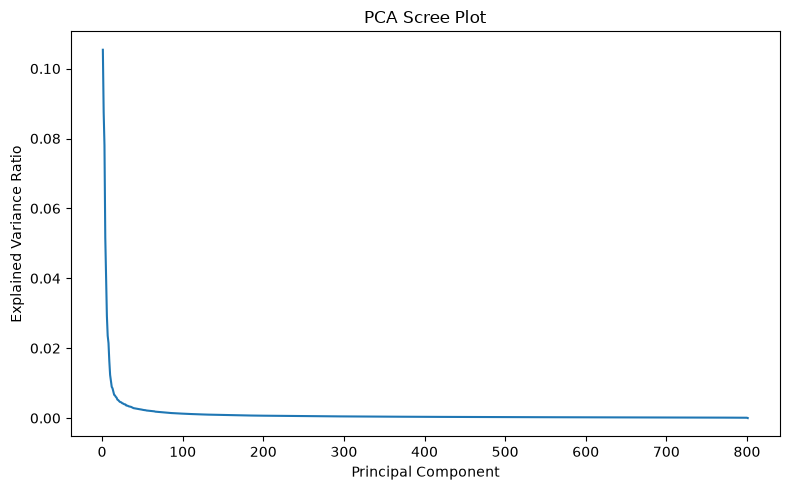

In [19]:
# Scree Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")

plt.tight_layout()

plt.savefig(
    figure_dir / "scree_plot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

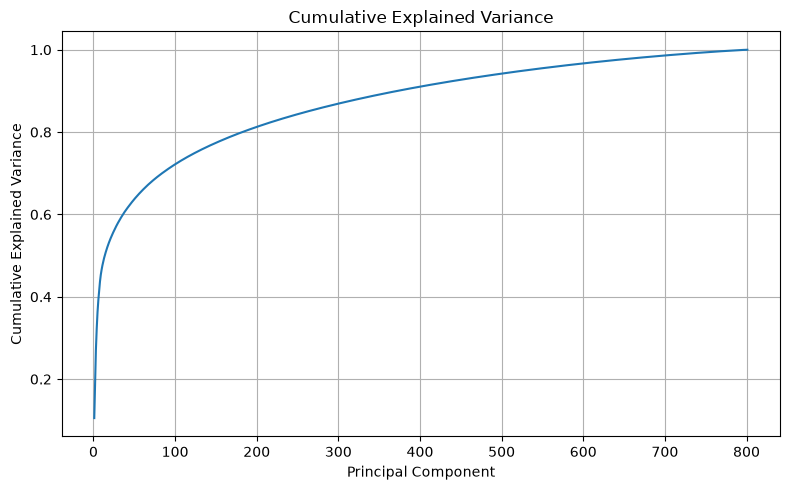

In [20]:
# Cumulative Variance
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    figure_dir / "cumulative_explained_variance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()